In [1]:
import os
import json
import pickle
import random
import numpy as np
import torch
import torchvision
from tqdm import tqdm
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as F
from skimage.draw import polygon as ski_polygon
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision.ops import box_iou
from sklearn.metrics import roc_curve, auc, f1_score

# Paths
data_path       = "/kaggle/input/datasets/sudhirkh/deepfashion2/DeepFashion2"
checkpoint_path = "/kaggle/input/datasets/sreenivasarajur/maskrcnn-transfer/maskrcnn_transfer.pth"
save_path       = "/kaggle/working/maskrcnn_transfer.pth"
scratch_path    = "/kaggle/working/maskrcnn_scratch.pth"

# Reproducibility
random.seed(42)
torch.manual_seed(42)
torch.backends.cudnn.benchmark = True

# Label mapping
TOP5        = [1, 8, 7, 2, 9]
cat_to_idx  = {cat_id: i for i, cat_id in enumerate(TOP5)}
idx_to_name = {
    0: "Short Sleeve Top",
    1: "Trousers",
    2: "Shorts",
    3: "Long Sleeve Top",
    4: "Skirt"
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Setup done.")

Device: cuda
Setup done.


In [2]:
# Load train paths
with open("/kaggle/input/datasets/sudhirkh/deepfashion-preprocessed/train_data.pkl", "rb") as f:
    train_image_paths, _ = pickle.load(f)

# Load val paths
with open("/kaggle/input/datasets/sudhirkh/deepfashion-preprocessed-val/validation_data.pkl", "rb") as f:
    val_image_paths, _ = pickle.load(f)

# Shuffle and subset
random.shuffle(train_image_paths)
random.shuffle(val_image_paths)

train_files = train_image_paths[:10000]
val_files   = val_image_paths[:5000]

print("Train images:", len(train_files))
print("Val images:  ", len(val_files))

Train images: 10000
Val images:   5000


In [3]:
class FashionDataset(Dataset):
    def __init__(self, image_paths):
        # Filter to only images whose annotation exists
        self.image_paths = []
        for p in image_paths:
            anno = p.replace("/image/", "/annos/").replace(".jpg", ".json")
            if os.path.exists(anno):
                self.image_paths.append(p)
        print(f"Dataset ready: {len(self.image_paths)} images")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path  = self.image_paths[idx]
        anno_path = img_path.replace("/image/", "/annos/").replace(".jpg", ".json")

        image    = Image.open(img_path).convert("RGB")
        W, H     = image.size

        with open(anno_path) as f:
            data = json.load(f)

        boxes, labels, masks = [], [], []

        for key in data:
            if not key.startswith("item"):
                continue
            item   = data[key]
            cat_id = item["category_id"]
            if cat_id not in cat_to_idx:
                continue

            x1, y1, x2, y2 = item["bounding_box"]
            # Skip degenerate boxes
            if x2 <= x1 or y2 <= y1:
                continue

            boxes.append([x1, y1, x2, y2])
            labels.append(cat_to_idx[cat_id] + 1)  # +1 for background

            # Build binary mask from polygons
            mask = np.zeros((H, W), dtype=np.uint8)
            for poly in item["segmentation"]:
                if len(poly) < 6:
                    continue
                px = np.array(poly[0::2]).clip(0, W - 1)
                py = np.array(poly[1::2]).clip(0, H - 1)
                rr, cc = ski_polygon(py, px, shape=(H, W))
                mask[rr, cc] = 1
            masks.append(mask)

        if len(boxes) == 0:
            boxes  = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,),   dtype=torch.int64)
            masks  = torch.zeros((0, H, W), dtype=torch.uint8)
        else:
            boxes  = torch.tensor(boxes,            dtype=torch.float32)
            labels = torch.tensor(labels,           dtype=torch.int64)
            masks  = torch.tensor(np.stack(masks),  dtype=torch.uint8)

        target = {"boxes": boxes, "labels": labels, "masks": masks}
        image  = F.to_tensor(image)

        return image, target

In [4]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = FashionDataset(train_files)
val_dataset   = FashionDataset(val_files)

train_loader = DataLoader(
    train_dataset, batch_size=4, shuffle=True,
    num_workers=2, collate_fn=collate_fn, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=4, shuffle=False,
    num_workers=2, collate_fn=collate_fn, pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:  ", len(val_loader))

Dataset ready: 10000 images
Dataset ready: 5000 images
Train batches: 2500
Val batches:   1250


In [5]:
image, target = train_dataset[0]
print("Image shape:", image.shape)
print("Boxes:",       target["boxes"])
print("Labels:",      target["labels"])
print("Masks shape:", target["masks"].shape)

Image shape: torch.Size([3, 831, 468])
Boxes: tensor([[  0., 128., 467., 565.]])
Labels: tensor([5])
Masks shape: torch.Size([1, 831, 468])


In [6]:
num_classes = 6  # 5 categories + background

model = maskrcnn_resnet50_fpn(weights="DEFAULT")

# Replace box predictor head
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Replace mask predictor head
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)

# Load epoch 7 checkpoint
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model = model.to(device)

print("Model loaded from epoch 7 checkpoint.")

Model loaded from epoch 7 checkpoint.


In [7]:
# SGD with same hyperparameters as original training
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

# StepLR reduces lr by gamma every step_size epochs
# We completed 7 epochs, so we step 7 times to get correct lr
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=3, gamma=0.1
)
for _ in range(7):
    scheduler.step()

print("Current LR:", scheduler.get_last_lr())
# Should be 0.005 * 0.1 * 0.1 = 0.000005 (stepped twice at epoch 3 and 6)

Current LR: [5e-05]


/tmp/ipykernel_155/1059922291.py:15: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


In [8]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    for images, targets in tqdm(loader):
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses    = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()
    return total_loss / len(loader)


def val_one_epoch(model, loader, device):
    model.train()  # train mode to get losses
    total_loss = 0
    with torch.no_grad():
        for images, targets in tqdm(loader):
            images  = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses    = sum(loss for loss in loss_dict.values())

            total_loss += losses.item()
    return total_loss / len(loader)

print("Training functions ready.")

Training functions ready.


In [ ]:
torch.cuda.empty_cache()

In [ ]:
num_epochs   = 2
best_val_loss = 0.2903  # best val loss from epoch 7

for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch + 8}/{num_epochs + 7}]")

    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss   = val_one_epoch(model, val_loader, device)
    scheduler.step()

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Current LR: {scheduler.get_last_lr()}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), save_path)
        print("✅ Model saved!")
    else:
        print("No improvement.")

print(f"\nTraining complete. Best Val Loss: {best_val_loss:.4f}")


--- Transfer Learning Model Evaluation ---
Running evaluation...


100%|██████████| 1250/1250 [29:51<00:00,  1.43s/it] 
/tmp/ipykernel_155/3240087922.py:104: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap = np.trapz(precision, recall)
/tmp/ipykernel_155/3240087922.py:104: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap = np.trapz(precision, recall)
/tmp/ipykernel_155/3240087922.py:104: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap = np.trapz(precision, recall)
/tmp/ipykernel_155/3240087922.py:104: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap = np.trapz(precision, recall)
/tmp/ipykernel_155/3240087922.py:104: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or on


DETECTION METRICS
Short Sleeve Top     AP: 0.9230 | F1: 0.6182 | AUC: 0.9417
Trousers             AP: 0.9429 | F1: 0.5579 | AUC: 0.9685
Shorts               AP: 0.8774 | F1: 0.3613 | AUC: 0.9395
Long Sleeve Top      AP: 0.7605 | F1: 0.4232 | AUC: 0.8970
Skirt                AP: 0.8435 | F1: 0.4915 | AUC: 0.9247

mAP@0.5:  0.8695
Macro F1: 0.4904
Mean AUC: 0.9343


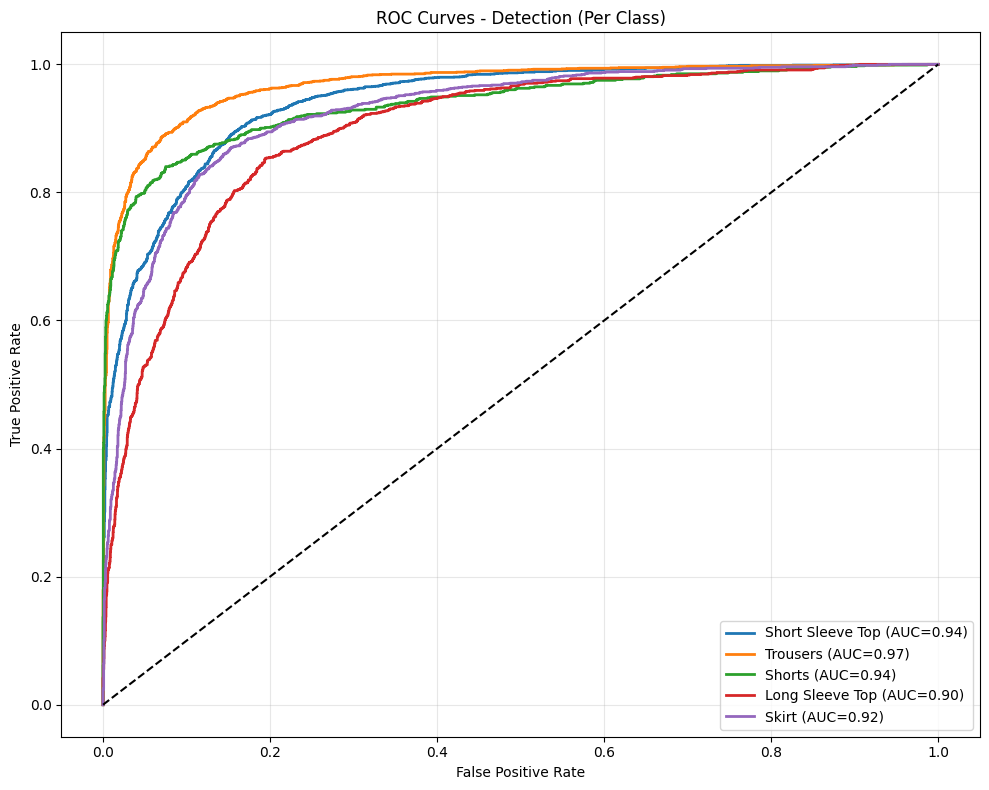


SEGMENTATION METRICS
Short Sleeve Top     IoU: 0.8933 | Dice: 0.9437
Trousers             IoU: 0.8496 | Dice: 0.9187
Shorts               IoU: 0.8528 | Dice: 0.9206
Long Sleeve Top      IoU: 0.8619 | Dice: 0.9258
Skirt                IoU: 0.8874 | Dice: 0.9403

mIoU:      0.8690
Mean Dice: 0.9298


In [9]:
def evaluate_model(model, loader, device, idx_to_name, iou_threshold=0.5):
    model.eval()
    num_classes = len(idx_to_name)

    # Detection tracking
    all_scores    = {i: [] for i in range(num_classes)}
    all_tp        = {i: [] for i in range(num_classes)}
    all_gt_counts = {i: 0  for i in range(num_classes)}

    # Segmentation tracking
    intersection = {i: 0 for i in range(num_classes)}
    union        = {i: 0 for i in range(num_classes)}
    dice_num     = {i: 0 for i in range(num_classes)}
    dice_den     = {i: 0 for i in range(num_classes)}

    print("Running evaluation...")
    with torch.no_grad():
        for images, targets in tqdm(loader):
            images = [img.to(device) for img in images]
            outputs = model(images)

            for output, target in zip(outputs, targets):
                pred_boxes  = output["boxes"].cpu()
                pred_labels = output["labels"].cpu()
                pred_scores = output["scores"].cpu()
                pred_masks  = (output["masks"].cpu().squeeze(1) > 0.5).float()

                gt_boxes    = target["boxes"]
                gt_labels   = target["labels"]
                gt_masks    = target["masks"].float()

                pred_labels_0 = pred_labels - 1
                gt_labels_0   = gt_labels - 1

                # Count ground truth per class
                for c in range(num_classes):
                    all_gt_counts[c] += (gt_labels_0 == c).sum().item()

                if len(pred_boxes) == 0 or len(gt_boxes) == 0:
                    for c in range(num_classes):
                        for s in pred_scores[pred_labels_0 == c]:
                            all_scores[c].append(s.item())
                            all_tp[c].append(0)
                    continue

                ious       = box_iou(pred_boxes, gt_boxes)
                gt_matched = torch.zeros(len(gt_boxes), dtype=torch.bool)

                for pi in range(len(pred_boxes)):
                    c = pred_labels_0[pi].item()
                    if c < 0 or c >= num_classes:
                        continue
                    score = pred_scores[pi].item()
                    all_scores[c].append(score)

                    best_iou, best_gi = -1, -1
                    for gi in range(len(gt_boxes)):
                        if gt_labels_0[gi].item() == c and not gt_matched[gi]:
                            if ious[pi, gi].item() > best_iou:
                                best_iou = ious[pi, gi].item()
                                best_gi  = gi

                    if best_iou >= iou_threshold and best_gi >= 0:
                        all_tp[c].append(1)
                        gt_matched[best_gi] = True

                        pred_mask = pred_masks[pi]
                        gt_mask   = gt_masks[best_gi]

                        inter = (pred_mask * gt_mask).sum().item()
                        uni   = ((pred_mask + gt_mask) > 0).float().sum().item()

                        intersection[c] += inter
                        union[c]        += uni
                        dice_num[c]     += 2 * inter
                        dice_den[c]     += pred_mask.sum().item() + gt_mask.sum().item()
                    else:
                        all_tp[c].append(0)

    # ── Detection Metrics ──
    print("\n" + "="*60)
    print("DETECTION METRICS")
    print("="*60)

    ap_list, auc_list, f1_list = [], [], []
    plt.figure(figsize=(10, 8))

    for c in range(num_classes):
        scores = np.array(all_scores[c])
        tps    = np.array(all_tp[c])
        n_gt   = all_gt_counts[c]

        if len(scores) == 0 or n_gt == 0:
            print(f"{idx_to_name[c]}: No predictions")
            continue

        sorted_idx = np.argsort(-scores)
        tps_sorted = tps[sorted_idx]
        cum_tp     = np.cumsum(tps_sorted)
        cum_fp     = np.cumsum(1 - tps_sorted)
        precision  = cum_tp / (cum_tp + cum_fp + 1e-6)
        recall     = cum_tp / (n_gt + 1e-6)

        ap = np.trapz(precision, recall)
        ap_list.append(ap)

        f1 = f1_score(tps, np.ones_like(tps), zero_division=0)
        f1_list.append(f1)

        if len(np.unique(tps)) > 1:
            fpr, tpr, _ = roc_curve(tps, scores)
            roc_auc     = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, label=f"{idx_to_name[c]} (AUC={roc_auc:.2f})")
        else:
            roc_auc = 0.0
        auc_list.append(roc_auc)

        print(f"{idx_to_name[c]:<20} AP: {ap:.4f} | F1: {f1:.4f} | AUC: {roc_auc:.4f}")

    print(f"\nmAP@0.5:  {np.mean(ap_list):.4f}")
    print(f"Macro F1: {np.mean(f1_list):.4f}")
    print(f"Mean AUC: {np.mean(auc_list):.4f}")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves - Detection (Per Class)")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ── Segmentation Metrics ──
    print("\n" + "="*60)
    print("SEGMENTATION METRICS")
    print("="*60)

    iou_list, dice_list = [], []
    for c in range(num_classes):
        if union[c] == 0:
            print(f"{idx_to_name[c]:<20} IoU: N/A | Dice: N/A")
            continue
        iou  = intersection[c] / (union[c] + 1e-6)
        dice = dice_num[c]     / (dice_den[c] + 1e-6)
        iou_list.append(iou)
        dice_list.append(dice)
        print(f"{idx_to_name[c]:<20} IoU: {iou:.4f} | Dice: {dice:.4f}")

    print(f"\nmIoU:      {np.mean(iou_list):.4f}")
    print(f"Mean Dice: {np.mean(dice_list):.4f}")

print("\n--- Transfer Learning Model Evaluation ---")
evaluate_model(model, val_loader, device, idx_to_name)

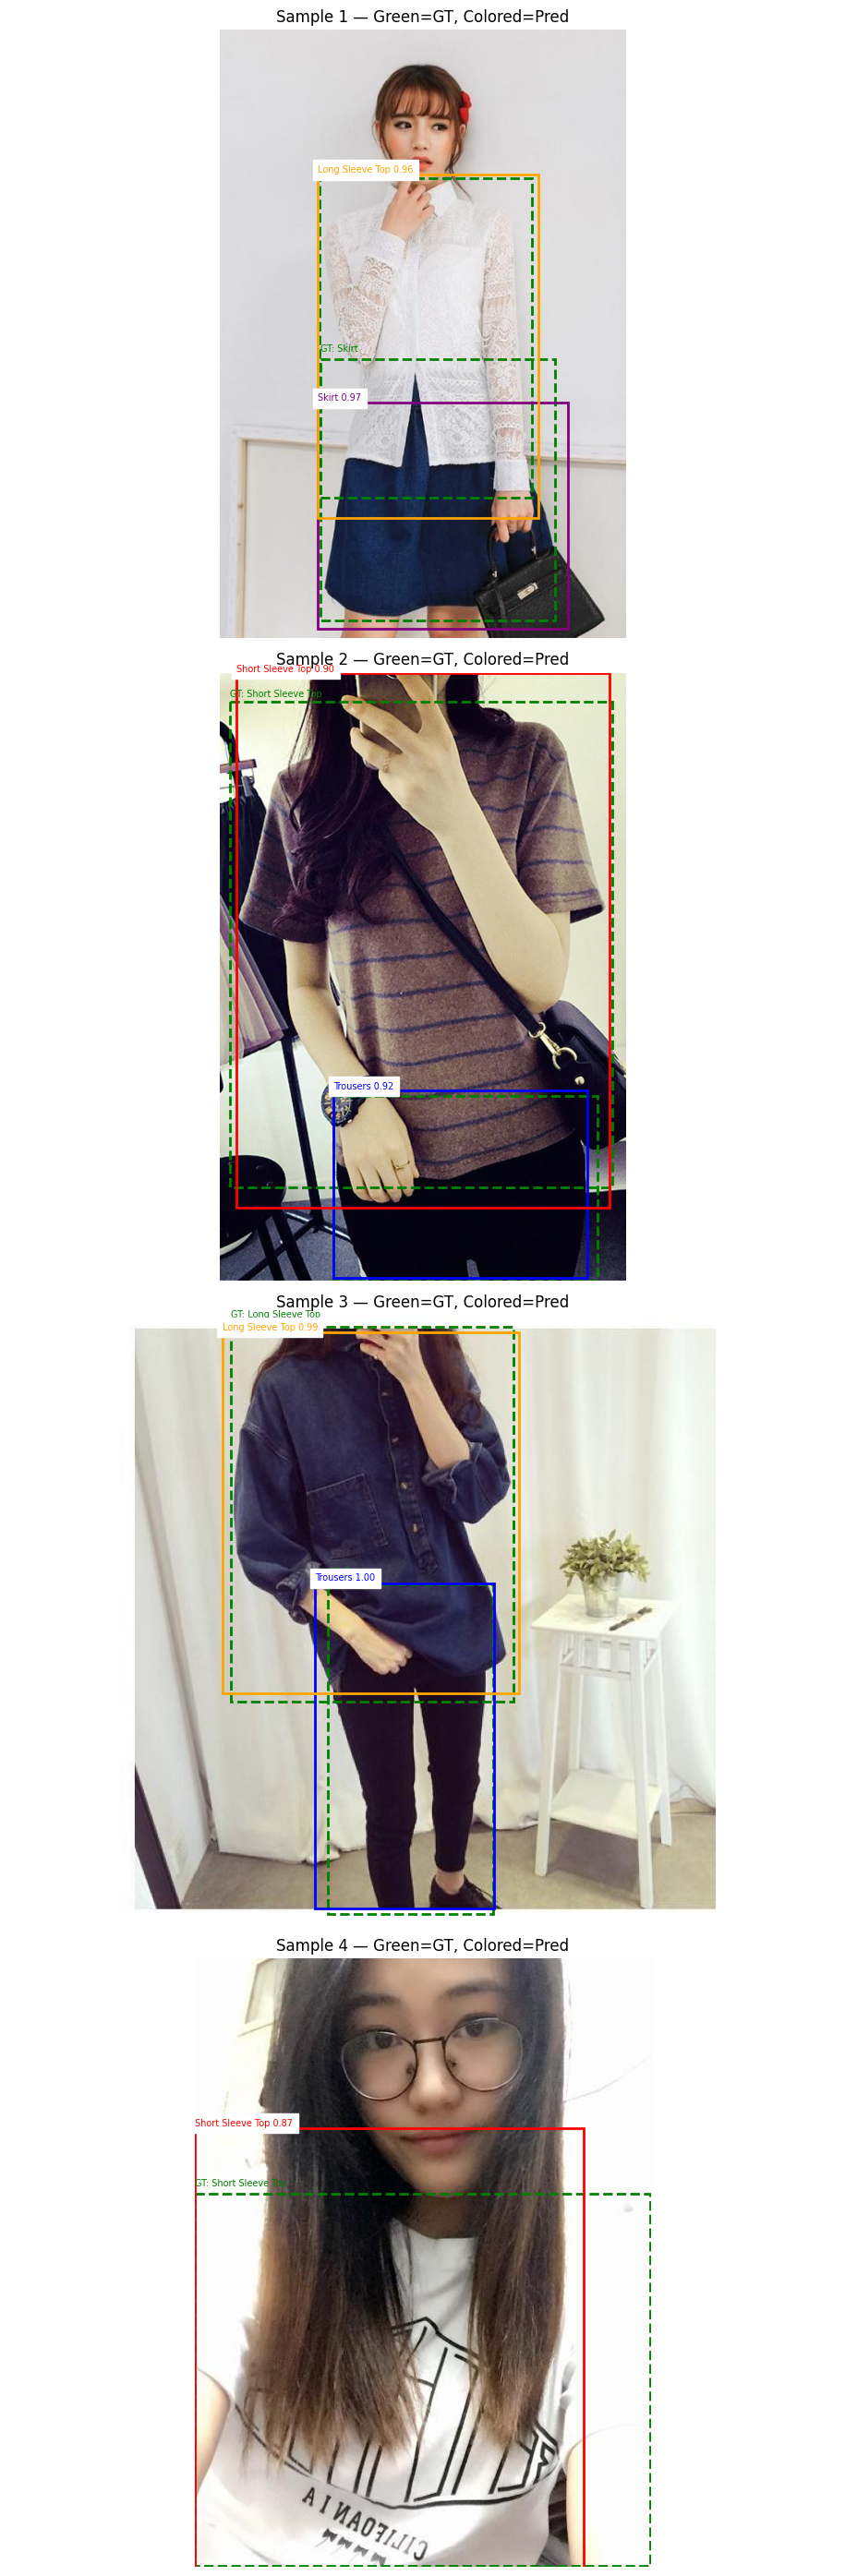

In [10]:
def visualize_predictions(model, dataset, device, idx_to_name, num_images=4, score_threshold=0.5):
    model.eval()
    fig, axes = plt.subplots(num_images, 1, figsize=(12, 7 * num_images))

    colors = ["red", "blue", "green", "orange", "purple"]

    for i in range(num_images):
        image, target = dataset[i]
        with torch.no_grad():
            output = model([image.to(device)])[0]

        img_np = image.permute(1, 2, 0).numpy()
        ax     = axes[i]
        ax.imshow(img_np)

        # Draw ground truth in green
        for box, label in zip(target["boxes"], target["labels"]):
            x1, y1, x2, y2 = box.tolist()
            cat = idx_to_name.get(label.item() - 1, "unknown")
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor="green", facecolor="none", linestyle="--"
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 8, f"GT: {cat}", color="green", fontsize=7)

        # Draw predictions in color
        for box, label, score in zip(
            output["boxes"].cpu(),
            output["labels"].cpu(),
            output["scores"].cpu()
        ):
            if score < score_threshold:
                continue
            x1, y1, x2, y2 = box.tolist()
            c    = label.item() - 1
            cat  = idx_to_name.get(c, "unknown")
            color = colors[c % len(colors)]
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor=color, facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 2, f"{cat} {score:.2f}", color=color, fontsize=7,
                    backgroundcolor="white")

        ax.set_title(f"Sample {i+1} — Green=GT, Colored=Pred")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_dataset, device, idx_to_name)

In [ ]:
model_scratch = maskrcnn_resnet50_fpn(weights=None)
in_features   = model_scratch.roi_heads.box_predictor.cls_score.in_features
model_scratch.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
in_features_mask = model_scratch.roi_heads.mask_predictor.conv5_mask.in_channels
model_scratch.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)
model_scratch = model_scratch.to(device)

optimizer_scratch = torch.optim.SGD(
    model_scratch.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005
)

best_val_loss_scratch = float("inf")

print("Scratch model initialized. Starting training...")

for epoch in range(2):
    print(f"\nEpoch [{epoch+1}/2]")
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer_scratch, device)
    val_loss   = val_one_epoch(model_scratch, val_loader, device)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")

    if val_loss < best_val_loss_scratch:
        best_val_loss_scratch = val_loss
        torch.save(model_scratch.state_dict(), scratch_path)
        print("✅ Scratch model saved!")

print(f"\nScratch training complete. Best Val Loss: {best_val_loss_scratch:.4f}")

In [ ]:
print("\n--- Scratch Model Evaluation ---")
evaluate_model(model_scratch, val_loader, device, idx_to_name)